In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
path = "../../results/surya_test_results.csv"
df = pd.read_csv(path)

In [13]:
def compute_scores(preds, target, threshold,eps=1e-7):
    preds = (preds >= threshold).astype(float)

    tp = (preds * target).sum()
    tn = ((1 - preds) * (1 - target)).sum()
    fp = (preds * (1 - target)).sum()
    fn = ((1 - preds) * target).sum()

    # accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)


    f1 = 2 * (precision * recall) / (precision + recall + eps)
    tss = recall + specificity - 1


    numerator = 2 * (tp * tn - fn * fp)
    denominator = (tp + fn) * (fn + tn) + (
        tp + fp
    ) * (tn + fp)
    hss = numerator / (denominator + eps)

    return f1, tss, hss

In [14]:
preds = df["predictions"]
targets = df["targets"]

In [15]:
f1, tss, hss = compute_scores(preds, targets, threshold=0.5)

In [47]:
f1_list = []
tss_list = []
hss_list = []
threshold_list = []

for threshold in np.arange(0.0, 1.0, 0.0005):
    f1, tss, hss = compute_scores(preds, targets, threshold)

    threshold_list.append(threshold)
    f1_list.append(f1)
    tss_list.append(tss)
    hss_list.append(hss)

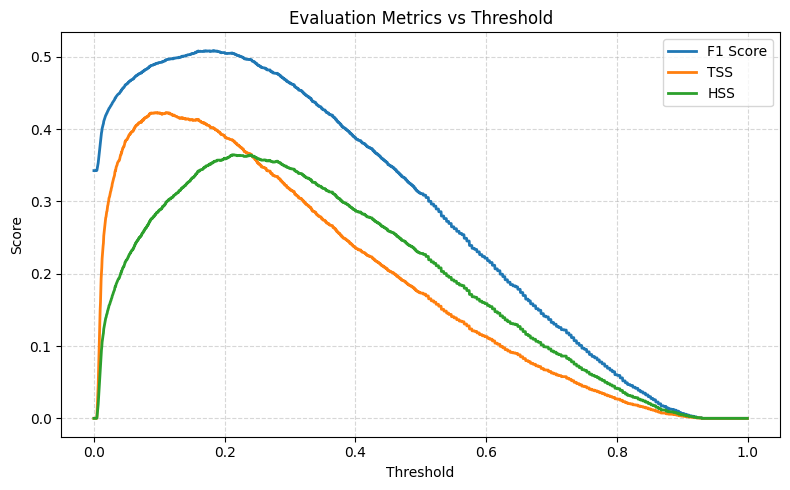

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_list, f1_list, label='F1 Score', linewidth=2)
plt.plot(threshold_list, tss_list, label='TSS', linewidth=2)
plt.plot(threshold_list, hss_list, label='HSS', linewidth=2)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Evaluation Metrics vs Threshold')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()